In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

PROJECT_ID = "fyxical-poc"
DATASET    = "fyxical_poc"
client     = bigquery.Client(project=PROJECT_ID)

df = client.query(f"SELECT * FROM `{PROJECT_ID}.{DATASET}.patient_pathways`").to_dataframe()
print(f"Rows: {len(df)}")
print(df["recommended_pathway"].value_counts().to_string())

Rows: 500
recommended_pathway
CHRONIC           296
ACUTE_SEVERE       76
SUBACUTE           67
ACUTE_MILD_MOD     61


In [2]:
# Acronym reference

ACRONYMS_CLINICAL = {
    "OSW"  : "Oswestry Disability Index — 0-100% disability scale used as a "
              "decision variable. Minimal 0-20% / Moderate 21-40% / "
              "Severe 41-60% / Crippled 61-80% / Bed-bound 81-100%.",
    "VAS"  : "Visual Analogue Scale — pain score 0-10 used as a decision variable. "
              "Mild 0-3 / Moderate 4-6 / Severe 7-10.",
    "ML"   : "Machine Learning — logistic regression trained to replicate rule engine.",
    "LR"   : "Logistic Regression — multiclass classification algorithm used here.",
    "HITL" : "Human-in-the-Loop — planned validation where a licensed PT "
              "independently labels edge cases as clinician-derived ground truth.",
    "POC"  : "Proof of Concept — this project stage. Not validated for clinical use.",
}

ACRONYMS_PATHWAYS = {
    "ACUTE_MILD_MOD" : "Acute + Mild/Moderate  — Pain score 0-6, Duration <2 weeks",
    "ACUTE_SEVERE"   : "Acute + Severe         — Pain score 7-10, Duration <2 weeks",
    "SUBACUTE"       : "Subacute               — Duration 2-12 weeks, any severity",
    "CHRONIC"        : "Chronic / High Burden  — Duration >12 weeks OR high OSW disability",
}

print("=" * 65)
print("  ACRONYM REFERENCE — Notebook 04")
print("=" * 65)

print("\n── Clinical & Project Terms ────────────────────────────────")
for code, desc in ACRONYMS_CLINICAL.items():
    print(f"\n  {code}")
    words = desc.split()
    line = "    "
    for word in words:
        if len(line) + len(word) + 1 > 64:
            print(line)
            line = "    " + word + " "
        else:
            line += word + " "
    print(line.rstrip())

print("\n── Pathway Codes (target variable) ─────────────────────────")
for code, desc in ACRONYMS_PATHWAYS.items():
    print(f"  {code:<16} {desc}")

print("\n" + "=" * 65)

  ACRONYM REFERENCE — Notebook 04

── Clinical & Project Terms ────────────────────────────────

  OSW
    Oswestry Disability Index — 0-100% disability scale used as 
    a decision variable. Minimal 0-20% / Moderate 21-40% / 
    Severe 41-60% / Crippled 61-80% / Bed-bound 81-100%.

  VAS
    Visual Analogue Scale — pain score 0-10 used as a decision 
    variable. Mild 0-3 / Moderate 4-6 / Severe 7-10.

  ML
    Machine Learning — logistic regression trained to replicate 
    rule engine.

  LR
    Logistic Regression — multiclass classification algorithm 
    used here.

  HITL
    Human-in-the-Loop — planned validation where a licensed PT 
    independently labels edge cases as clinician-derived ground 
    truth.

  POC
    Proof of Concept — this project stage. Not validated for 
    clinical use.

── Pathway Codes (target variable) ─────────────────────────
  ACUTE_MILD_MOD   Acute + Mild/Moderate  — Pain score 0-6, Duration <2 weeks
  ACUTE_SEVERE     Acute + Severe         — 

In [3]:
# Feature Engineering

dur_order  = [["Acute","Subacute","Chronic"]]
enc_dur    = OrdinalEncoder(categories=dur_order)
df["pain_duration_enc"] = enc_dur.fit_transform(df[["pain_duration_category"]])

pain_order = [["Mild","Moderate","Severe"]]
enc_pain   = OrdinalEncoder(categories=pain_order)
df["pain_severity_enc"] = enc_pain.fit_transform(df[["pain_severity_category"]])

osw_order  = [["Minimal","Moderate","Severe","Crippled","Bed-bound"]]
enc_osw    = OrdinalEncoder(categories=osw_order)
df["osw_category_enc"]  = enc_osw.fit_transform(df[["osw_baseline_disability_category"]])

print("Ordinal encodings applied:")
print(f"  pain_duration  : {dict(zip(dur_order[0],  range(len(dur_order[0]))))}")
print(f"  pain_severity  : {dict(zip(pain_order[0], range(len(pain_order[0]))))}")
print(f"  osw_category   : {dict(zip(osw_order[0],  range(len(osw_order[0]))))}")

Ordinal encodings applied:
  pain_duration  : {'Acute': 0, 'Subacute': 1, 'Chronic': 2}
  pain_severity  : {'Mild': 0, 'Moderate': 1, 'Severe': 2}
  osw_category   : {'Minimal': 0, 'Moderate': 1, 'Severe': 2, 'Crippled': 3, 'Bed-bound': 4}


In [5]:
# Train / Test Split

feature_cols = [
    "pain_duration_weeks",
    "pain_severity_score_0_10",
    "osw_baseline_percent_disability",
    "pain_duration_enc",
    "pain_severity_enc",
    "osw_category_enc",
    "age",
]

X = df[feature_cols].values
y = df["recommended_pathway"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Features         : {feature_cols}")

Training samples : 400
Test samples     : 100
Features         : ['pain_duration_weeks', 'pain_severity_score_0_10', 'osw_baseline_percent_disability', 'pain_duration_enc', 'pain_severity_enc', 'osw_category_enc', 'age']


In [6]:
# Train model

model = LogisticRegression(
    max_iter=1000, multi_class="multinomial",
    solver="lbfgs", C=1.0, random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}  ({acc*100:.1f}%)")
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.9100  (91.0%)

                precision    recall  f1-score   support

ACUTE_MILD_MOD       1.00      0.67      0.80        12
  ACUTE_SEVERE       0.79      1.00      0.88        15
       CHRONIC       0.92      1.00      0.96        59
      SUBACUTE       1.00      0.64      0.78        14

      accuracy                           0.91       100
     macro avg       0.93      0.83      0.86       100
  weighted avg       0.92      0.91      0.90       100



/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [7]:
# Model framing

print(f"""
Model Validation: Corrected Framing
======================================

Current POC Result:
  Accuracy ({acc*100:.1f}%) = agreement with rule-assigned labels on held-out
  test set (n={len(y_test)}). This reflects how consistently the model
  replicates the rule engine logic - NOT clinical predictive validity.

Why this distinction matters:
  Labels were generated by our own rule engine using three variables:
    - pain_duration_weeks
    - pain_severity_score_0_10
    - osw_baseline_percent_disability
  High accuracy means the model learned those rules successfully.
  It does NOT mean the rules themselves produce good patient outcomes.

What this POC model CAN claim:
  ✓ Rule logic is consistent and learnable across unseen patients
  ✓ Pathway assignment can be automated at scale without the rule engine
  ✓ Feature importance is interpretable (see coefficient heatmap below)
  ✓ Foundation is in place for clinical validation once real data exists

What this POC model CANNOT claim:
  ✗ Predictive validity against real patient recovery outcomes
  ✗ Clinical superiority over standard PT triage
  ✗ Generalisability to real patient populations

Planned upgrade: HITL Validation (see Notebook 05 roadmap):
  A licensed PT on our team will independently label n=50-75
  edge cases blind to rule outputs. Model will be re-evaluated
  against PT labels, converting the accuracy metric from
  rule-agreement to clinical-expert-agreement.
""")


Model Validation: Corrected Framing

Current POC Result:
  Accuracy (91.0%) = agreement with rule-assigned labels on held-out
  test set (n=100). This reflects how consistently the model
  replicates the rule engine logic - NOT clinical predictive validity.

Why this distinction matters:
  Labels were generated by our own rule engine using three variables:
    - pain_duration_weeks
    - pain_severity_score_0_10
    - osw_baseline_percent_disability
  High accuracy means the model learned those rules successfully.
  It does NOT mean the rules themselves produce good patient outcomes.

What this POC model CAN claim:
  ✓ Rule logic is consistent and learnable across unseen patients
  ✓ Pathway assignment can be automated at scale without the rule engine
  ✓ Feature importance is interpretable (see coefficient heatmap below)
  ✓ Foundation is in place for clinical validation once real data exists

What this POC model CANNOT claim:
  ✗ Predictive validity against real patient recovery out

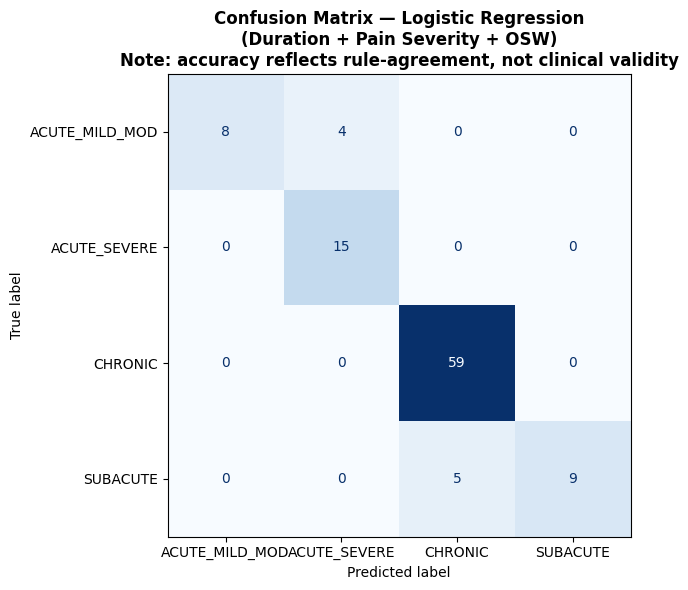

In [8]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(
    "Confusion Matrix — Logistic Regression\n"
    "(Duration + Pain Severity + OSW)\n"
    "Note: accuracy reflects rule-agreement, not clinical validity",
    fontweight="bold"
)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

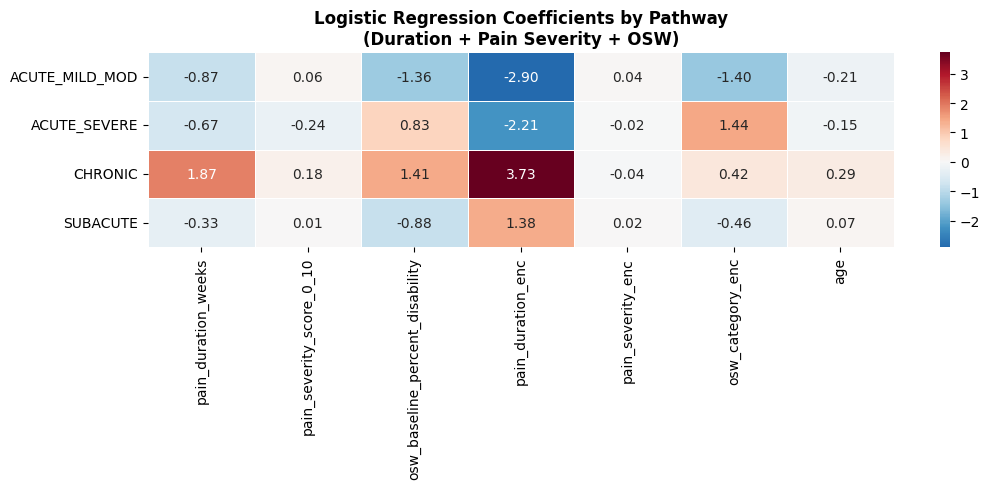

In [9]:
# Feature coefficients heatmap

coef_df = pd.DataFrame(model.coef_, columns=feature_cols, index=model.classes_)
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(coef_df, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.5, ax=ax)
ax.set_title(
    "Logistic Regression Coefficients by Pathway\n"
    "(Duration + Pain Severity + OSW)",
    fontweight="bold"
)
plt.tight_layout()
plt.savefig("feature_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# Export predictions to BigQuery

from google.cloud.bigquery import LoadJobConfig, WriteDisposition

df_full = df.reset_index(drop=True)
_, test_idx = train_test_split(
    df_full.index, test_size=0.2, random_state=42,
    stratify=df_full["recommended_pathway"]
)
df_export = df_full.loc[test_idx].copy()
df_export["predicted_pathway"]  = model.predict(X_test)
df_export["prediction_correct"] = (
    df_export["predicted_pathway"] == df_export["recommended_pathway"]
)

job_config = LoadJobConfig(write_disposition=WriteDisposition.WRITE_TRUNCATE, autodetect=True)
job = client.load_table_from_dataframe(
    df_export, f"{PROJECT_ID}.{DATASET}.model_predictions", job_config=job_config
)
job.result()
print(f"Exported {len(df_export)} predictions → model_predictions")

Exported 100 predictions → model_predictions
